# Customer Segmentation using RFM Analysis

## Project Overview

Customer segmentation is one of the most important techniques used in Customer Relationship Management (CRM). Businesses can improve customer retention, increase revenue, and design personalized marketing campaigns by understanding customer purchasing behavior.

This project applies **RFM Analysis (Recency, Frequency, Monetary Value)** on an online retail dataset to identify valuable customer groups and generate actionable business insights.

---

# Business Problem

Companies often struggle to answer questions such as:

* Who are the most valuable customers?
* Which customers are at risk of churn?
* Which customers purchase frequently?
* How can marketing campaigns be personalized?

To solve these challenges, this project segments customers based on their purchasing history using the RFM framework.

---

# Dataset

**Online Retail II Dataset (2009–2011)**

The dataset contains transactional records from an online retail company.

### Features

| Feature     | Description                |
| ----------- | -------------------------- |
| Invoice     | Transaction ID             |
| StockCode   | Product ID                 |
| Description | Product Description        |
| Quantity    | Number of Units Purchased  |
| InvoiceDate | Transaction Date           |
| Price       | Unit Price                 |
| Customer ID | Unique Customer Identifier |
| Country     | Customer Country           |

---

# Project Workflow

## 1. Data Cleaning

The following preprocessing steps were performed:

* Removed missing values
* Removed duplicate records
* Validated data quality
* Created a new feature:

```python
Total_Amount = Quantity × Price
```

This feature represents the revenue generated from each transaction.

---

## 2. Feature Engineering

### Monetary Value

The total spending of each customer was calculated.

### Recency

Recency measures how recently a customer made a purchase.

```text
Recency = Reference Date - Last Purchase Date
```

A smaller recency value indicates a more active customer.

### Frequency

Frequency measures how often a customer purchases.

```text
Frequency = Total Number of Purchases
```

### Monetary

Monetary value measures the total amount spent.

```text
Monetary = Total Customer Revenue
```

---

# RFM Analysis

Customers were grouped by Customer ID and the following metrics were calculated:

### Recency

Days since last purchase.

### Frequency

Number of transactions.

### Monetary Value

Total spending.

The resulting RFM table serves as the foundation for customer segmentation.

---

# RFM Scoring

Quartile-based scoring was used.

Each customer receives a score from 1 to 4 for:

* Recency (R)
* Frequency (F)
* Monetary (M)

Higher scores indicate better customer behavior.

Example:

| R | F | M | RFM Score |
| - | - | - | --------- |
| 4 | 4 | 4 | 12        |
| 4 | 3 | 4 | 11        |
| 1 | 1 | 1 | 3         |

---

# Customer Segmentation

Customers were categorized into:

### High Value Customers

Characteristics:

* Recent purchases
* Frequent purchases
* High spending

Business Action:

* Loyalty programs
* Exclusive offers
* Premium services

---

### Mid Value Customers

Characteristics:

* Moderate purchasing activity

Business Action:

* Personalized promotions
* Cross-selling opportunities

---

### Low Value Customers

Characteristics:

* Infrequent purchases
* Low spending

Business Action:

* Re-engagement campaigns
* Discount offers

---

# Advanced Customer Segments

Additional business-focused segments were created:

### VIP / Loyal Customers

Customers with:

* High Recency Score
* High Frequency Score
* High Monetary Score

These customers generate the largest share of revenue.

---

### Potential Loyalists

Customers who purchase regularly and show strong engagement.

---

### At-Risk Customers

Customers who previously purchased frequently but have become inactive.

---

### Lost Customers

Customers who have not purchased for a long period.

---

# Visualizations

Several interactive visualizations were developed using Plotly:

## Customer Distribution by Segment

Shows the number of customers in each RFM category.

---

## Treemap Analysis

Visualizes customer groups and their relative sizes.

---

## VIP Customer Analysis

Boxplots were used to analyze:

* Recency
* Frequency
* Monetary Value

for VIP customers.

---

## Correlation Analysis

A heatmap was created to understand relationships among:

* Recency Score
* Frequency Score
* Monetary Score

This helps identify behavioral patterns within high-value customers.

---

# Key Insights

### High-Value Customers

A small percentage of customers contribute a significant portion of revenue.

### Customer Retention Opportunity

Several customers show declining activity and can be targeted through retention campaigns.

### Revenue Optimization

VIP customers should receive loyalty rewards to maximize lifetime value.

### Marketing Personalization

Different customer groups require different marketing strategies.

---

# Business Impact

Implementing RFM segmentation enables businesses to:

* Improve customer retention
* Increase customer lifetime value (CLV)
* Reduce churn
* Personalize marketing campaigns
* Optimize promotional spending

---

# Technologies Used

* Python
* Pandas
* NumPy
* Plotly
* Seaborn
* Jupyter Notebook

---

# Conclusion

This project demonstrates how RFM Analysis can transform raw transaction data into actionable customer intelligence. By identifying customer value and purchasing behavior, businesses can create targeted marketing strategies, improve retention, and increase profitability.

Future enhancements may include:

* Customer Lifetime Value (CLV) Prediction
* Churn Prediction Models
* Machine Learning-Based Segmentation
* Marketing Recommendation Systems


# Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors
import seaborn as sns
from datetime import datetime,timedelta



In [2]:
df=pd.read_excel('online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


# Dataset Exploration

In [4]:
print(df.shape)

(525461, 8)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB
None


<Axes: >

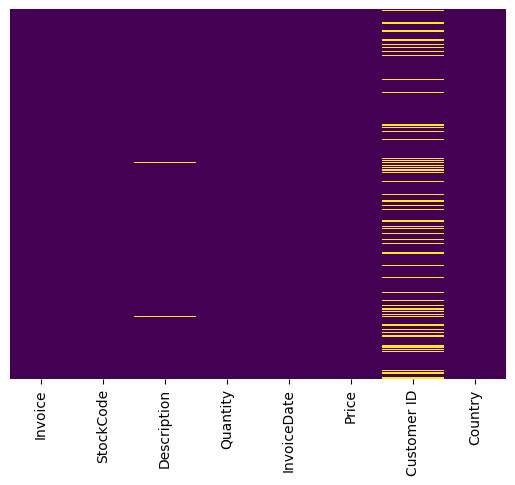

In [6]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [7]:
df=df.dropna()

In [8]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [9]:
df.shape

(417534, 8)

In [10]:
df.duplicated().sum()

np.int64(6771)

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

### Observation   
Missing Values and duplicated are removed as they have a very small amount , it will not effect our analysis

In [13]:
df['Total_Amount']=df['Quantity']*df['Price']

### insights    
We had "Quantity" column and "Price " column but we had not any as Total_Amount or tottal_sum which is a very important one for RFM anlysis there we have created one from the existing columns

In [14]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [15]:
# referecence date 
reference_date = pd.Timestamp(datetime.now().date())

In [16]:
reference_date

Timestamp('2026-06-10 00:00:00')

In [17]:

reference_date=df['InvoiceDate'].max()+ timedelta(days=1)

In [18]:
reference_date

Timestamp('2010-12-10 20:01:00')

###  since the data is from 2009-2010 therefore we will choose the reference date closer to 2010..

In [19]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Recency Frequency and Monetory Value

In [20]:
# now we will calculate the RFM " Recency Frequency and Monetory Value"
rfm=df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x:(reference_date - x.max()).days,
    'Invoice':'count',
    'Total_Amount':'sum'
})

In [21]:
rfm.rename(columns={'InvoiceDate':'Recency','Invoice':'Frequency','Total_Amount':'Value'},inplace=True)

In [22]:
rfm.head()

,Recency,Frequency,Value
Customer ID,,,
12346.0,67,45,-51.74
12347.0,3,71,1323.32
12348.0,74,20,222.16
12349.0,43,107,2646.99
12351.0,11,21,300.93


In [23]:
#Define Quantile
quantiles=rfm.quantile(q=(0.25,0.50,0.75))

#Assign RFM scores 
def RScore(x,p,d):
    if p=='Recency':
        if x<= d[p][0.25]:
            return 4
        elif x<=d[p][0.50]:
            return 3
        elif x<=d[p][0.75]:
             return 2
        else:
         return 1
    else:
        if x<= d[p][0.25]:
            return 1
        elif x<=d[p][0.50]:
            return 2
        elif x<=d[p][0.75]:
             return 3
        else:
         return 4

In [24]:
rfm['R']=rfm['Recency'].apply(RScore,args=('Recency',quantiles,))
rfm['F']=rfm['Frequency'].apply(RScore,args=('Frequency',quantiles,))
rfm['M']=rfm['Value'].apply(RScore,args=('Value',quantiles,))


In [25]:
rfm.head()

,Recency,Frequency,Value,R,F,M
Customer ID,,,,,,
12346.0,67,45,-51.74,2,3,1
12347.0,3,71,1323.32,4,3,3
12348.0,74,20,222.16,2,2,1
12349.0,43,107,2646.99,3,4,4
12351.0,11,21,300.93,4,2,2


>Elements of Recency represents days
### Observation   
The value -51.74 indicates customers who returned the products... 



In [26]:
rfm['RFM_segment']=rfm['R'].astype(str)+rfm['F'].astype(str)+rfm['M'].astype(str)
rfm['RFM_score']=rfm[['R','F','M']].sum(axis=1)

In [27]:
rfm.head()

,Recency,Frequency,Value,R,F,M,RFM_segment,RFM_score
Customer ID,,,,,,,,
12346.0,67,45,-51.74,2,3,1,231,6
12347.0,3,71,1323.32,4,3,3,433,10
12348.0,74,20,222.16,2,2,1,221,5
12349.0,43,107,2646.99,3,4,4,344,11
12351.0,11,21,300.93,4,2,2,422,8


In [28]:
segment_label=['Low_value','Mid','High_value']
def assign_label(score):
    if score<5:
        return "Low_value"
    elif score<9:
        return "Mid_value"
    else:
        return "High_value"

rfm['RFM_segement_Label']=rfm['RFM_score'].apply(assign_label)
rfm.head()

,Recency,Frequency,Value,R,F,M,RFM_segment,RFM_score,RFM_segement_Label
Customer ID,,,,,,,,,
12346.0,67,45,-51.74,2,3,1,231,6,Mid_value
12347.0,3,71,1323.32,4,3,3,433,10,High_value
12348.0,74,20,222.16,2,2,1,221,5,Mid_value
12349.0,43,107,2646.99,3,4,4,344,11,High_value
12351.0,11,21,300.93,4,2,2,422,8,Mid_value


In [29]:
segment_counts=rfm['RFM_segement_Label'].value_counts().reset_index()
segment_counts.columns=['RFM_segment','Count']
segment_counts=segment_counts.sort_values('RFM_segment')

In [30]:
fig = px.bar(segment_counts,
             x='RFM_segment',
             y='Count',
             title='Customer Distribution by RFM Segment',
             color='RFM_segment',
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

### Insights    
We have around 1700 loyal customers , 1900 mid_value customer and around 800  customers have low_value indicating that the market team need to pay attention to this group in order to top them from leaving

In [31]:
# 1. Initialize the column with consistent spelling
rfm['RFM_Customer_Segments'] = ''

# 2. Apply segmentation using correct .loc syntax, brackets, and parentheses
rfm.loc[rfm['RFM_score'] >= 9, 'RFM_Customer_Segments'] = "VIP/Loyal"
rfm.loc[(rfm['RFM_score'] >= 6) & (rfm['RFM_score'] < 9), 'RFM_Customer_Segments'] = "Potential Loyal"
rfm.loc[(rfm['RFM_score'] >= 5) & (rfm['RFM_score'] < 6), 'RFM_Customer_Segments'] = "At Risk Customer"
rfm.loc[(rfm['RFM_score'] >= 4) & (rfm['RFM_score'] < 5), 'RFM_Customer_Segments'] = "Can't Lose"
rfm.loc[(rfm['RFM_score'] >= 3) & (rfm['RFM_score'] < 4), 'RFM_Customer_Segments'] = "Lost"

# 3. Add parentheses to value_counts()
segment_counts = rfm['RFM_Customer_Segments'].value_counts().sort_index()


In [32]:
rfm.head()

,Recency,Frequency,Value,R,F,M,RFM_segment,RFM_score,RFM_segement_Label,RFM_Customer_Segments
Customer ID,,,,,,,,,,
12346.0,67,45,-51.74,2,3,1,231,6,Mid_value,Potential Loyal
12347.0,3,71,1323.32,4,3,3,433,10,High_value,VIP/Loyal
12348.0,74,20,222.16,2,2,1,221,5,Mid_value,At Risk Customer
12349.0,43,107,2646.99,3,4,4,344,11,High_value,VIP/Loyal
12351.0,11,21,300.93,4,2,2,422,8,Mid_value,Potential Loyal


In [33]:
segment_product_counts=rfm.groupby(['RFM_segement_Label','RFM_Customer_Segments']).size().reset_index(name='Count')
segment_product_counts=segment_product_counts.sort_values('Count',ascending=False)


In [34]:
# Create the treemap
fig_treemap_segment_product=px.treemap(segment_product_counts,
                                       path=['RFM_segement_Label','RFM_Customer_Segments'],
                                       values='Count',
                                       color='RFM_segement_Label',
                                       color_discrete_sequence=px.colors.qualitative.Pastel,
                                       title='RFM Customer Segments By Value',
                                       width=1000,   
                                       height=600 )
fig_treemap_segment_product.show()


In [35]:
vip_segment=rfm[rfm['RFM_Customer_Segments']=="VIP/Loyal"]

In [36]:
fig=go.Figure()
fig.add_trace(go.Box(y=vip_segment['Recency'],name='Recency'))
fig.add_trace(go.Box(y=vip_segment['Frequency'],name='Frequency'))
fig.add_trace(go.Box(y=vip_segment['Value'],name='Value'))


In [38]:
rfm.head()

,Recency,Frequency,Value,R,F,M,RFM_segment,RFM_score,RFM_segement_Label,RFM_Customer_Segments
Customer ID,,,,,,,,,,
12346.0,67,45,-51.74,2,3,1,231,6,Mid_value,Potential Loyal
12347.0,3,71,1323.32,4,3,3,433,10,High_value,VIP/Loyal
12348.0,74,20,222.16,2,2,1,221,5,Mid_value,At Risk Customer
12349.0,43,107,2646.99,3,4,4,344,11,High_value,VIP/Loyal
12351.0,11,21,300.93,4,2,2,422,8,Mid_value,Potential Loyal


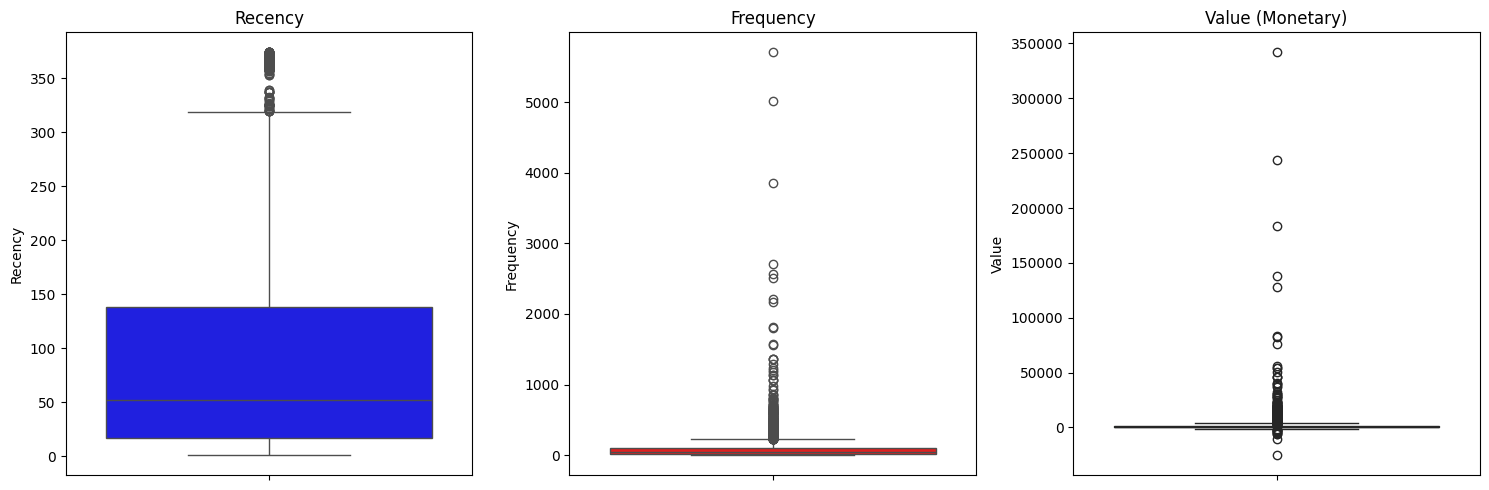

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each metric individually with its own scale
sns.boxplot(y=rfm['Recency'], ax=axes[0], color='blue').set_title('Recency')
sns.boxplot(y=rfm['Frequency'], ax=axes[1], color='red').set_title('Frequency')
sns.boxplot(y=rfm['Value'], ax=axes[2], color='green').set_title('Value (Monetary)')

plt.tight_layout()
plt.show()


# OBSERVATION   
>Most customors purchases goods around 0-150 days after their previous purchase but some can vary upto 350 days   
>Most of the time 0-100 items are purchased but sometimes it can go upto 5000 of item in a single order indicates the VIP customers


In [45]:
correlation_matrix=vip_segment[['R','F','M']].corr()

In [47]:
fig_heatmap=go.Figure(data=go.Heatmap(
                      z=correlation_matrix.values,
                      y=correlation_matrix.columns,
                      x=correlation_matrix.columns,
                      colorscale='RdBu',
                      colorbar=dict(title='Correlation')))
fig_heatmap.update_layout(title='Correlation Matrix of RFM values with in VIP Segment')
fig_heatmap.show()

In [48]:
pastel_colors = plotly.colors.qualitative.Pastel
fig = go.Figure(data=[go.Bar(x=segment_counts.index, y=segment_counts.values,
                             marker=dict(color=pastel_colors))])

# Set the color of the Champions segment as a different color
vip_color = "rgb(158, 202, 225)"
fig.update_traces(marker_color=[vip_color if segment == 'Champions' else pastel_colors[i]
                                for i, segment in enumerate(segment_counts.index)],
                  marker_line_color='rgb(8, 48, 107)',
                  marker_line_width=1.5, opacity=0.6)

# Update the layout
fig.update_layout(title='Comparison of RFM Segments',
                  xaxis_title='RFM Segments',
                  yaxis_title='Number of Customers',
                  showlegend=False)

# Display the figure
fig.show()


In [49]:
# Calculate the mean R, F, and M scores for each customer segment
segment_scores = rfm.groupby('RFM_Customer_Segments')[['R', 'F', 'M']].mean().reset_index()
fig = go.Figure()

# Add bars for Recency score
fig.add_trace(go.Bar(
    x=segment_scores['RFM_Customer_Segments'],
    y=segment_scores['R'],
    name='Recency Score',
    marker_color='rgb(158,202,225)'
))

# Add bars for Frequency score
fig.add_trace(go.Bar(
    x=segment_scores['RFM_Customer_Segments'],
    y=segment_scores['F'],
    name='Frequency Score',
    marker_color='rgb(94,158,217)'
))

# Add bars for Monetary score
fig.add_trace(go.Bar(
    x=segment_scores['RFM_Customer_Segments'],
    y=segment_scores['M'],
    name='Monetary Score',
    marker_color='rgb(32,102,148)'
))

# Update the layout
fig.update_layout(
    title='Comparison of RFM Segments based on Recency, Frequency, and Monetary Scores',
    xaxis_title='RFM Segments',
    yaxis_title='Score',
    barmode='group'
)

# Display the figure
fig.show()
